Контекст
Вы работаете в отделе безопасности крупного банка. Перед вами стоит критически важная задача: разработать систему обнаружения мошеннических операций по кредитным картам в реальном времени. Для этого вам предоставили анонимизированный датасет транзакций.

Датасет: [Credit Card Fraud Detection]( https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "creditcard.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)

/tmp/ipython-input-2076715507.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.


Постановка задачи
Проведите сравнительный анализ алгоритмов машинного обучения для задачи бинарной классификации транзакций на:

Легальные (Class = 0)

Мошеннические (Class = 1)

# Задача 1. Предобработка данных (1 балл)

- Изучите распределение целевой переменной (анализ дисбаланса классов). Постройте графики

- Проведите масштабирование признаков (V1-V28 уже нормализованы, но Time и Amount требуют обработки)

- Разделите данные на обучающую и тестовую выборки (учтите стратификацию из-за дисбаланса)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error, f1_score

In [ ]:
print(f"Размер df: {df.shape} \n df head: \n")
df.head()

Размер df: (284807, 31) 
 df head: 



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Распределение классов: \n")
print(df['Class'].value_counts())
print("\nПроцентное соотношение: \n")
print(df['Class'].value_counts(normalize=True) * 100)
print("Пропущенные значения:", df.isnull().sum().sum())

Распределение классов: 

Class
0    284315
1       492
Name: count, dtype: int64

Процентное соотношение: 

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Пропущенные значения: 0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


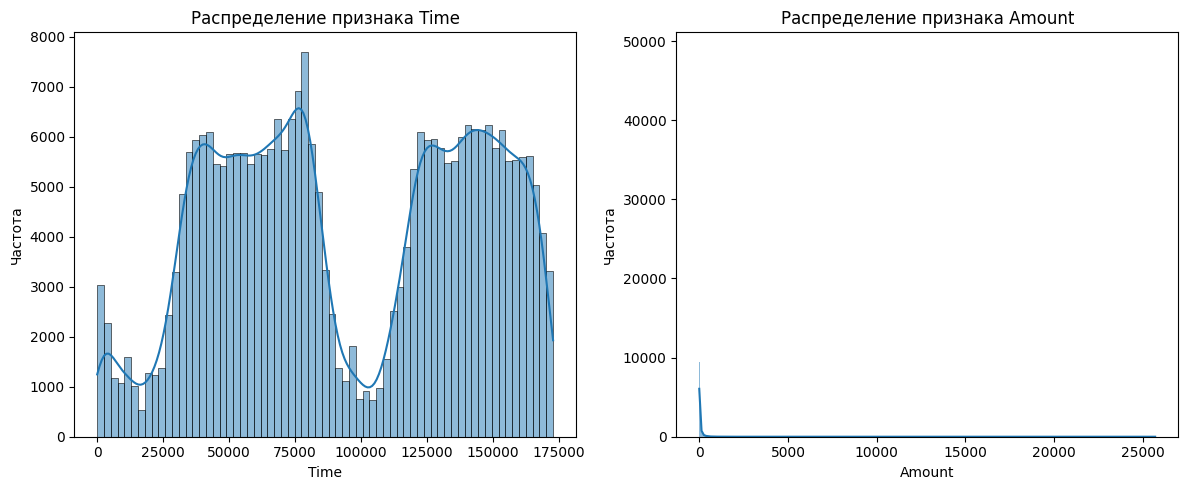

In [ ]:
import seaborn as sns

num_columns = df.shape[1]
num_rows = 1

plt.figure(figsize=(18, 5 * num_rows))

for i, column in enumerate(['Time', 'Amount']):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Распределение признака {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

Мы видим, что есть выбросы, а распределение Time - не нормальное и вообще не равняется никакому из известных распределений, а значит, на основе этого можно будет выбрать тип нормализации данных в этих столбцах.

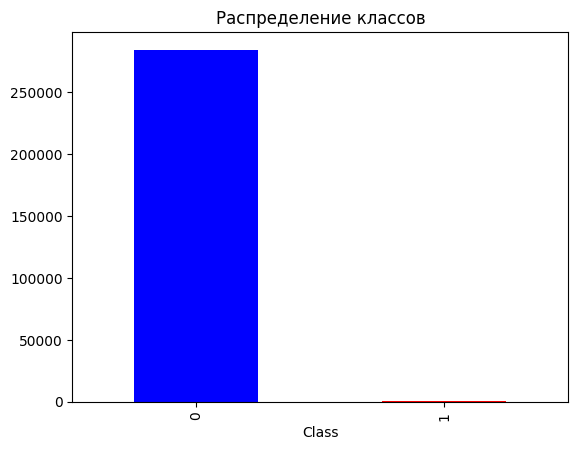

In [ ]:
df['Class'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Распределение классов')
plt.show()

Почти все признаки уже нормализованы, осталось нормализовать Time и Amount. Так как по графику видно наличие выбросов в Amount, а Time, тоже судя по графикам, не распределён нормально, можно попробовать использовать RobustScaler.

In [6]:
from sklearn.preprocessing import RobustScaler
df_norm = df.copy()
scaler = RobustScaler()
df_norm[['Time', 'Amount']] = scaler.fit_transform(df_norm[['Time', 'Amount']])

In [7]:
X = df_norm.drop('Class', axis=1)
y = df_norm['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36, stratify=y)

print(f"Размер обучающей выборки X: {X_train.shape}")
print(f"Размер тестовой выборки X: {X_test.shape}")
print(f"Распределение классов в обучающей выборке:\n{y_train.value_counts(normalize=True)}")
print(f"Распределение классов в тестовой выборке:\n{y_test.value_counts(normalize=True)}")

Размер обучающей выборки X: (199364, 30)
Размер тестовой выборки X: (85443, 30)
Распределение классов в обучающей выборке:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64
Распределение классов в тестовой выборке:
Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


# Задача 2. Построение   моделей ( 2 балла)

Реализуйте следующие алгоритмы:

Базовые модели:

- Линейная регрессия (с пороговой функцией)

- kNN (k-ближайших соседей)

- Решающее дерево

Ансамблевые методы:

- Бэггинг (BaggingClassifier)

- Случайный лес (Random Forest)

- Стекинг (StackingClassifier) для моделей

  *   LogisticRegression,
  *  KNeighborsClassifier,
  *  DecisionTreeClassifier


Может долго работать, но примерно до 15-20 минут !

***
P.S. - если я правильно поняла, то в первом пункте от нас просят всё же логистическую регрессию (в ней можно и классы взвесить, и она подходит под задачу классификации, и порог задаётся как раз по этому же поводу), к тому же, в категории с ансамблевыми методами тоже упоминается логистическая регрессия. Так что, я надеюсь, что именно она имелась в виду))

**Базовые модели:**
1. Логистическая регрессия (class_weight='balanced' нужен, так как данные в датасете очень несбалансированы по целевому признаку и нужно дать классу-мошеннику больший вес для корректного обучения, порог (threshold) сделаем стандартным - 0.5)
2. KNN
3. Решающее дерево

In [ ]:
from sklearn.linear_model import LogisticRegression

threshold = 0.5
log_reg = LogisticRegression(class_weight='balanced', random_state=13, max_iter=5000)
log_reg.fit(X_train, y_train)
y_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred_log_reg = (y_prob > threshold).astype(int)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(class_weight='balanced', random_state=13, max_depth=15,
                              min_samples_split=5, min_samples_leaf=5)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

**Ансамблевые методы:**

1. Бэггинг (BaggingClassifier) - копии модели обучаются на разных выборках из данных (это регулируется несколькими параметрами, например, bootstrap), а затем из нескольких предсказаний выбирается наиболее частое.

2. Случайный лес (Random Forest) - копии моделей обучаются на разных выборках и в каждой выборке рандомизированно выбирается набор признаков, по которым будет происходить обучение.

3. Стекинг (StackingClassifier) для моделей:
  - LogisticRegression,
  - KNeighborsClassifier,
  - DecisionTreeClassifier

Стекинг - несколько разных моделей ( в нашем случае knn, logistic regression и decision tree classifier) обучаются на данных, затем разультаты попадают в мета-модель, которая тоже обучается и выдаёт финальный результат

In [ ]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(estimator=tree, n_estimators=100, random_state=18, n_jobs=-1)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=13,
                            max_depth=15, min_samples_split=5, min_samples_leaf=5, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.ensemble import StackingClassifier

base_models = [('log_r', LogisticRegression(class_weight='balanced')),
              ('knn', KNeighborsClassifier()),
              ('tree', DecisionTreeClassifier(class_weight='balanced'))]
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

# Задача 3. Оценка моделей ( 2 балла )

Для каждой модели рассчитайте:

- Precision и Recall

- F1-score (основная метрика из-за дисбаланса)

- ROC-AUC

- Матрицу ошибок (Confusion Matrix)

Подсказка: Мы оцениваем на тестовой выборке

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def print_metrics(y_true, y_pred, model_name):
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    ra = roc_auc_score(y_true, y_pred)
    print(f"=== {model_name} ===")
    print("Precision: ", prec)
    print("Recall:    ", rec)
    print("--------")
    print("F1-Score:  ", f1)
    print("--------")
    print("ROC-AUC: ", ra)
    print("Матрица ошибок:")
    print(confusion_matrix(y_true, y_pred))
    print()
    return {
        "Model": model_name,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": ra
    }

In [ ]:
all_data = {"Логистическая регрессия" : y_pred_log_reg,
            "KNN" : y_pred_knn,
            "Решающее дерево" : y_pred_tree,
            "Бэггинг" : y_pred_bag,
            "Случайный лес" : y_pred_rf,
            "Стеккинг" : y_pred_stack}

results_list = []
for (name, pred) in all_data.items():
  result = print_metrics(y_test, pred, name)
  results_list.append(result)

=== Логистическая регрессия ===
Precision:  0.06419868791002811
Recall:     0.9256756756756757
--------
F1-Score:   0.1200701139351446
--------
ROC-AUC:  0.9511314072147063
Матрица ошибок:
[[83298  1997]
 [   11   137]]

=== KNN ===
Precision:  0.8714285714285714
Recall:     0.8243243243243243
--------
F1-Score:   0.8472222222222222
--------
ROC-AUC:  0.9120566460123292
Матрица ошибок:
[[85277    18]
 [   26   122]]

=== Решающее дерево ===
Precision:  0.29439252336448596
Recall:     0.8513513513513513
--------
F1-Score:   0.4375
--------
ROC-AUC:  0.923905349161812
Матрица ошибок:
[[84993   302]
 [   22   126]]

=== Бэггинг ===
Precision:  0.8456375838926175
Recall:     0.8513513513513513
--------
F1-Score:   0.8484848484848485
--------
ROC-AUC:  0.9255408494842224
Матрица ошибок:
[[85272    23]
 [   22   126]]

=== Случайный лес ===
Precision:  0.802547770700637
Recall:     0.8513513513513513
--------
F1-Score:   0.8262295081967214
--------
ROC-AUC:  0.9254939534176301
Матрица ошибок

In [ ]:
results_df = pd.DataFrame(results_list)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Логистическая регрессия,0.064199,0.925676,0.120070,0.951131
1,KNN,0.871429,0.824324,0.847222,0.912057
2,Решающее дерево,0.294393,0.851351,0.437500,0.923905
3,Бэггинг,0.845638,0.851351,0.848485,0.925541
4,Случайный лес,0.802548,0.851351,0.826230,0.925494
5,Стеккинг,0.916667,0.817568,0.864286,0.908719


Выводы:
- Проанализируем сначала по метрике Recall (если задача банка - не пропустить мошенничество, то это именно эта метрика будет для нас информативной): логистическая регрессия - 0.9257, решающее дерево и бэггинг - 0.8514. Однако важно заметить, что логистическая регрессия имеет низкий precision (0.0642), который, к тому же, заметно ниже этого показателя на других моделях. Она даёт много ложных срабатываний, что на практике - плохо: блокирование 15 легальных транзакций ради обнаружения 1 мошеннической.


Значит, нельзя анализировать только эту метрику. Давайте рассмотрим f1-score (среднее гармоническое между precision и recall):

Здесь явно выделяются решающее дерево и логистическая регрессия (низкие показатели). Логистическая регрессия плохо отработала, вероятно, из-за значительного дисбаланса классов и сильной чувствительности к этому, а решающее дерево также имеет низкий precision из-за переобучения (так как эта модель склонна к нему сильнее всех). Поэтому важно использовать ансамбли. Они работают лучше одиночных моделей. Давайте рассмотрим их результаты:

- Стеккинг имеет самый высокий precision среди ансамблевых методов и при этом не сильно уступает в recall, однако roc-auc метрика незначительно меньше, чем эти же показатели на бэггинге и случайном лесе.

- Бэггинг находится в "золотой середине" по всем показателям, но здесь я бы выделила, что в моём случае метод отработал за 13 минут, когда стеккинг работал 7. В дальнейшем мне придётся полбирать оптимальные параметры, поэтому, конечно, хочется, чтобы этот подбор работал разумное время, и даже оптимизация всего в 2 раза значительно сэкономит время, при этом практически не теряя в качестве, а где-то и улучшая метрики.

Дополнительно хочется выделить метод K ближайших соседей.

- KNN отработал, на удивление, хорошо. Возможно, просто точки образуют хорошо различимые алгоритмом "группы"/"кластеры". Я бы связала такой хороший результат с везением и особенностями конкретного датасета. Это замечательно, что мы нашли хорошо работающую модель, но в общем случае на данных с сильным дисбалансом knn не имеет никаких преимуществ.

# Задача 4. Сравнительный анализ ( 1 балл)

Создайте сводную таблицу со всеми метриками и проведите анализ:

- Какая модель показывает наилучшее качество?

- Какие модели лучше обнаруживают мошеннические транзакции (высокий recall)?

- Какие модели минимизируют ложные срабатывания (высокий precision)?

Ответы:

Я уже много выводов написала в прошлом задании, которые в целом подойдут и сюда :)
Поэтому здесь постараюсь кратко продублировать основные факты.

- **Наилучшее качество:** Стеккинг — F1-Score = 0.8714 и максимальный Precision = 0.9242. к тому же, оптимальный по времени в сравнении с бэггингом
- **Высокий recall:** Логистическая регрессия — Recall = 0.9257. Но большое число ложный срабатываний (precision всего 0.0641). Бэггинг, решающее дерево, случайный лес - recall = 0.8514 (но у дерева тоже низкий precision).
- **Высокий precision:** Стеккинг (precision = 0.9242). Немного отстают в этом показателе KNN (precision = 0.8714) и бэггинг — (precision = 0.8456)

In [ ]:
results_df = pd.DataFrame(results_list)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Логистическая регрессия,0.064199,0.925676,0.120070,0.951131
1,KNN,0.871429,0.824324,0.847222,0.912057
2,Решающее дерево,0.294393,0.851351,0.437500,0.923905
3,Бэггинг,0.845638,0.851351,0.848485,0.925541
4,Случайный лес,0.802548,0.851351,0.826230,0.925494
5,Стеккинг,0.916667,0.817568,0.864286,0.908719


# Задача 5. Углубленный анализ ошибок ( 2 балла)
- Проанализируйте ложно-положительные и ложно-отрицательные случаи лучшей модели

- Определите паттерны в транзакциях, которые модель классифицирует неправильно

- Визуализируйте распределение ошибок по признакам Amount и Time

In [ ]:
fp = np.where((y_test == 0) & (y_pred_stack == 1))[0]
fn = np.where((y_test == 1) & (y_pred_stack == 0))[0]
tp = np.where((y_test == 1) & (y_pred_stack == 1))[0]
tn = np.where((y_test == 0) & (y_pred_stack == 0))[0]

print(f"Ложноположительные: {fp.size}, в процентах - {fp.size / (y_test == 1).size * 100:.2f} % относительно всех положительных")
print(f"Ложноотрицательные: {fn.size}, в процентах - {fn.size / (y_test == 0).size * 100:.2f} % относительно всех отрицательных")

print(f"\nВсего мошенничеств в тесте: {(y_test == 1).size}")
print(f"Из них найдено правильно: {(y_test == 1).size - fn.size}")
print(f"Эффективность обнаружения: {((y_test == 1).size - fn.size) / (y_test == 1).size * 100:.5f}%")

original_amount_test = df.loc[X_test.index, 'Amount']
print(f"\nАнализ исходных сумм (по столбцу 'Amount'):")
print(f"Средняя сумма FP: {original_amount_test.iloc[fp].mean():.2f} ед.")
print(f"Средняя сумма FN: {original_amount_test.iloc[fn].mean():.2f} ед.")
print(f"Средняя сумма легальных операций: {original_amount_test[y_test == 0].mean():.2f} ед.")
print(f"Средняя сумма мошеннических операций: {original_amount_test[y_test == 1].mean():.2f} ед.")

Ложноположительные: 11, в процентах - 0.01 % относительно всех положительных
Ложноотрицательные: 27, в процентах - 0.03 % относительно всех отрицательных

Всего мошенничеств в тесте: 85443
Из них найдено правильно: 85416
Эффективность обнаружения: 99.96840%

Анализ исходных сумм (по столбцу 'Amount'):
Средняя сумма FP: 107.69 ед.
Средняя сумма FN: 254.75 ед.
Средняя сумма легальных операций: 87.78 ед.
Средняя сумма мошеннических операций: 131.96 ед.


In [ ]:
def print_top(name):
  diffs = []
  for col in X_test.columns:
    if name == 'fp':
      diff = abs(X_test.iloc[fp][col].mean() - X_test[y_test == 0][col].mean())
    else:
      diff = abs(X_test.iloc[fn][col].mean() - X_test[y_test == 1][col].mean())
    diffs.append((col, diff))
  diffs.sort(key=lambda x: x[1], reverse=True)
  print(f"{name}, топ признаков по ошибкам:")
  for i, (col, diff) in enumerate(diffs[:3], 1):
      print(f"{i}. {col}: {diff:.4f}")

print_top('fp')
print_top('fn')

fp, топ признаков по ошибкам:
1. V3: 13.7378
2. V1: 12.5351
3. V7: 9.6193
fn, топ признаков по ошибкам:
1. V17: 6.3601
2. V3: 5.4823
3. V7: 5.4512


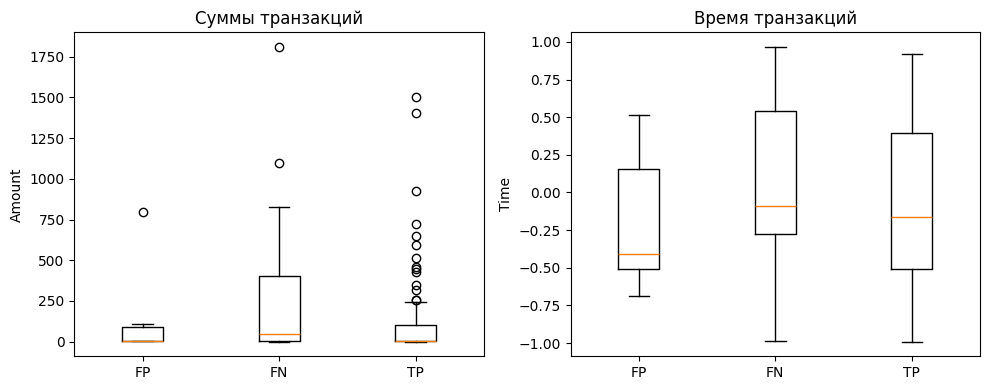

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot([
    original_amount_test.iloc[fp].values,
    original_amount_test.iloc[fn].values,
    original_amount_test.iloc[tp].values
], tick_labels=['FP', 'FN', 'TP'])
plt.title('Суммы транзакций')
plt.ylabel('Amount')

plt.subplot(1, 2, 2)
plt.boxplot([
    X_test.iloc[fp]['Time'].values,
    X_test.iloc[fn]['Time'].values,
    X_test.iloc[tp]['Time'].values
], tick_labels=['FP', 'FN', 'TP'])
plt.title('Время транзакций')
plt.ylabel('Time')

plt.tight_layout()
plt.show()

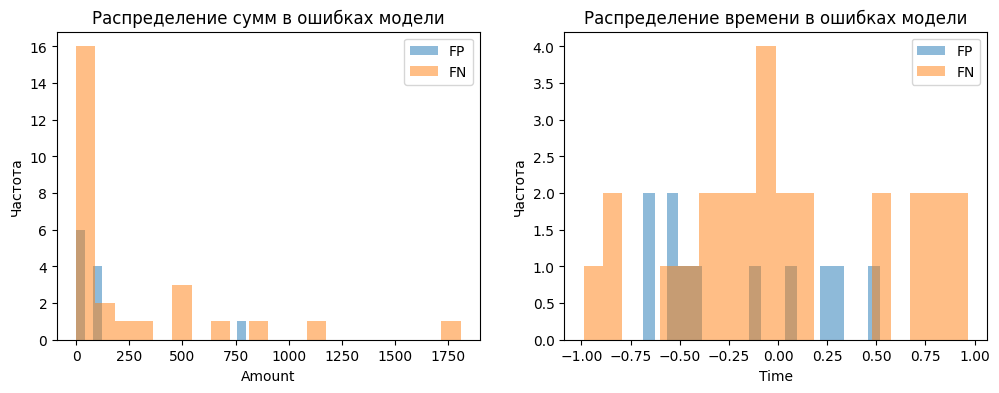

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(original_amount_test.iloc[fp].values, bins=20, alpha=0.5, label='FP')
axes[0].hist(original_amount_test.iloc[fn].values, bins=20, alpha=0.5, label='FN')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение сумм в ошибках модели')
axes[0].legend()

axes[1].hist(X_test.iloc[fp]['Time'], bins=20, alpha=0.5, label='FP')
axes[1].hist(X_test.iloc[fn]['Time'], bins=20, alpha=0.5, label='FN')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение времени в ошибках модели')
axes[1].legend()

Выводы:

- Ложноотрицательные результаты заметно чаще встречаются среди транзакций с низкой суммой переводов. В целом, и ложноположительные тоже, но мне кажется, что это пока сложно оценить из-за небольшого количества ложноположительных результатов.
- Репределение времени в ошибках модели близко к равномерному, откуда можно предположить, что время между транзакциями не сильно влияет на ошибку в ответе.
- Всего мошенничеств в тесте: 85443. Из них найдено правильно: 85417. В процентах: 99.96957%, что показывает высокое качество модели.
- Признаки, разница в которых была наибольшая для данных, в которых допущена ошибка: V1, V7 - для обоих ошибок (и fp, и fn), а также V1 для ложноположительных ответов и V17 для ложноотрицательных. При этом в среднем размер ошибки для ложноположительных результатов больше, чем для ложноотрицательных.

# Задача 6. Подбор гиперпараметров (2 балла)

- Подберите оптимальные гиперпараметры с помощью [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) для лучшей модели.
-  Построй модель с лучшими параметрами и оцени
- Напиши выводы о лучшей модели.

Лучшая модель - стеккинг. Она состоит из нескольких других моделей, которые запускаются отдельно, а результат вычисляется из результатов этих моделей. Поэтому гиперпараметры будем перебирать как раз для "внутренних" моделей стеккинга, причём по отдельности, так как это поможет . Чтобы программа закончилась за разумное время, менять я буду самые, на мой взгляд, "влиятельные" параметры (например, для решающего дерева это его глубина, так как именно это влияет на переобучаемость модели, для knn - это, конечно, количество соседей, а для финальной модели - логистической регрессии - это степень регуляризации). Сделаем подбор параметров для каждой "внутренней модели", а затем объединим их.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    'n_neighbors': [3, 9, 15],
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, scoring='f1', cv=3, n_jobs=-1)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_

In [9]:
tree_params = {'max_depth': [5, 7, 10]}
tree_grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'), tree_params, scoring='f1', cv=3)
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_


In [10]:
logreg_params = {'C': [0.01, 0.1, 1, 10]}
logreg_grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=500), logreg_params, scoring='f1', cv=3)
logreg_grid.fit(X_train, y_train)
best_logreg = logreg_grid.best_estimator_

In [13]:
from sklearn.ensemble import StackingClassifier
stacking = StackingClassifier(
    estimators=[
        ('lr', best_logreg),
        ('knn', best_knn),
        ('tree', best_tree)
    ],
    final_estimator=LogisticRegression()
)

stacking.fit(X_train, y_train)

StackingClassifier(estimators=[('lr',
                                LogisticRegression(C=0.01,
                                                   class_weight='balanced',
                                                   max_iter=500)),
                               ('knn', KNeighborsClassifier(n_neighbors=3)),
                               ('tree',
                                DecisionTreeClassifier(class_weight='balanced',
                                                       max_depth=10))],
                   final_estimator=LogisticRegression())

In [16]:
best_stacking = stacking
y_pred_best = best_stacking.predict(X_test)

In [17]:
print(f"\nF1 на тестовых данных: {f1_score(y_test, y_pred_best):.4f}")


F1 на тестовых данных: 0.8561


Выводы:

В ходе попыток найти оптимальные параметры самостоятельно, я пришла к f1-score = 0.8561. Это высокий показатель, однако на изначальном методе стеккинга, состоящем из моделей с дефолтными параметрами, метрика f1 приблизительно на 0.05 больше. Отсюда стоит сделать вывод, что подбирать параметры - никогда не лишняя работа, которая может привести к улучшению метрик, но значения по дефолту на то и выбраны разрабочиками библиотек, что для большой части задач они показывают оптимальный результат по различным метрикам. Также я убедилась, что подбор параметров очень затратен по времени, поэтому делать это нужно с умом и, наверное, каким-либо образом для себя обосновать необходимость подбора тех или иных гиперпараметров.